In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
import os
sys.path.append(os.path.abspath('..'))
from scripts import analysis_utils as au
from scipy.ndimage import gaussian_filter
from scipy.optimize import curve_fit
plt.rcParams.update({'font.size': 10})
plt.rcParams['axes.grid'] = False
import matplotlib as mpl
mpl.rcParams['font.family'] = 'monospace' 
from sps_common.constants import DM_CONSTANT, FREQ_BOTTOM, FREQ_TOP, TSAMP
from ps_processes.processes.ps_inject import gaussian

In [2]:
data_1 = np.concatenate((np.loadtxt('single_day_20260402_results.txt'),
                         np.loadtxt('single_day_2026_04_05_injections.txt'),
                         np.loadtxt('single_day_2026_04_08_injections.txt'),
                         np.loadtxt('single_day_2026_04_11_injections.txt'),
                         np.loadtxt('single_day_2026_04_14_injections.txt')))
data_1[:, 2] = 1
data_5 = np.loadtxt('5_day_injections.txt')
data_6 = np.loadtxt('6_day_injections.txt')
data_7 = np.loadtxt('7_day_injections.txt')
data_8 = np.loadtxt('8_day_injections.txt')
data_9 = np.loadtxt('9_day_injections.txt')
data_10 = np.loadtxt('10_day_injections.txt')
data_11 = np.loadtxt('11_day_injections.txt')
data_12 = np.loadtxt('12_day_injections.txt')
data_13 = np.loadtxt('13_day_injections.txt')
data_14 = np.loadtxt('14_day_injections.txt')
data_15 = np.loadtxt('15_day_injections.txt')
data_16 = np.loadtxt('16_day_injections.txt')
data_17 = np.loadtxt('17_day_injections.txt')
data_18 = np.loadtxt('18_day_injections.txt')
data_19 = np.loadtxt('19_day_injections.txt')
data_20 = np.loadtxt('20_day_injections.txt')

f_idx = 4
DM_idx = 5
S_idx = 6

In [3]:
p_total = []

data_unglob = [
    data_1,
    data_10,
    data_11,
    data_12,
    data_13,
    data_14,
    data_15,
    data_16,
    data_17,
    data_18,
    data_19,
    data_20
]

data = []
days = []

for datum in data_unglob:

    fglob_mask = (datum[:, f_idx] > 0.1) & (datum[:, f_idx] < 250.)
    DMglob_mask = (datum[:, DM_idx] > 1.) & (datum[:, DM_idx] < 600.)
    Sglob_mask = datum[:, S_idx] > 0.1
    glob_mask = fglob_mask & DMglob_mask & Sglob_mask
    datum = datum[glob_mask]

    p = len(datum[datum[:, -1] > 0.]) / len(datum)
    print(f'{int(datum[0, 2])}-day stack: {len(datum)} injections, p({int(datum[0, 2])}) = {p:.2f}')
    p_total.append(p)
    days.append(datum[0, 2])

    data.append(datum)

days = np.array(days)

1-day stack: 15528 injections, p(1) = 0.55
10-day stack: 4340 injections, p(10) = 0.71
11-day stack: 12284 injections, p(11) = 0.75
12-day stack: 23251 injections, p(12) = 0.76
13-day stack: 35829 injections, p(13) = 0.78
14-day stack: 22396 injections, p(14) = 0.78
15-day stack: 5405 injections, p(15) = 0.75
16-day stack: 11906 injections, p(16) = 0.77
17-day stack: 8898 injections, p(17) = 0.78
18-day stack: 17332 injections, p(18) = 0.80
19-day stack: 15613 injections, p(19) = 0.80
20-day stack: 4099 injections, p(20) = 0.79


Text(0, 0.5, 'p(N)')

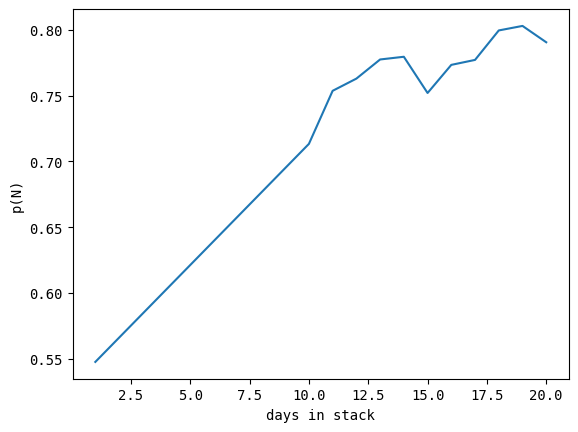

In [4]:
plt.plot(days, p_total)
plt.xlabel('days in stack')
plt.ylabel('p(N)')

/data1/people/rsquillace/Transmissivity/scripts/analysis_utils.py:32: RuntimeWarning: invalid value encountered in divide
  arr_ret_p_smooth = arr_ret_smooth / arr_inj_smooth
/data1/people/rsquillace/Transmissivity/scripts/analysis_utils.py:34: RuntimeWarning: invalid value encountered in divide
  arr_ret_p = arr_retrieved / arr_injected


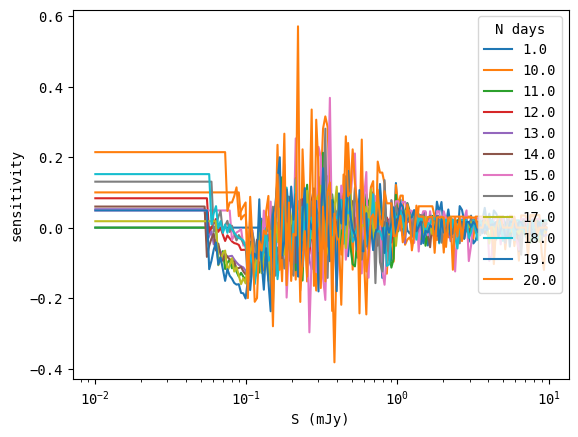

In [5]:
S_idx = 6
S_bins = np.logspace(-2, 1, 200)
S_dev = 10

S_curve = np.zeros((len(data), len(S_bins) - 1))
S_50 = np.zeros(len(data))
S_10 = np.zeros(len(data))
S_1 = np.zeros(len(data))
S_err50_up = np.zeros(len(data))
S_err10_up = np.zeros(len(data))
S_err10_down = np.zeros(len(data))
S_err1_up = np.zeros(len(data))
S_err1_down = np.zeros(len(data))

for i in range(len(data)):

    _, S_sens, S_smooth = au.get_sensitivity(
        data[i],
        *(S_idx, S_bins, S_dev)
    )

    plt.plot(S_bins[:-1], S_sens - S_smooth, label = days[i])
    # plt.plot(S_bins[:-1], S_smooth, '--')
    # plt.plot(S_bins[:-1], S_sens - S_smooth, '--')

    S_curve[i] = S_sens
    #S_smooth = gaussian_filter(S_sens, 3)
    S_50[i] = np.max(S_bins[np.where(S_smooth < 0.5)[0]])
    S_10[i] = np.max(S_bins[np.where(S_smooth < 0.1)[0]])
    S_1[i] = np.max(S_bins[np.where(S_smooth < 0.01)[0]])

    p_80_idx = np.where(S_smooth < 0.5)[0][-1]
    local_std50 = np.std(S_sens[p_80_idx - 10: p_80_idx + 10])
    S_err50_up[i] = np.max(S_bins[np.where(S_smooth < 0.5 + local_std50)[0]])

    p_10_idx = np.where(S_smooth < 0.1)[0][-1]
    local_std10 = np.std(S_sens[p_10_idx - 10:p_10_idx + 10])
    S_err10_up[i] = np.max(S_bins[np.where(S_smooth < 0.1 + local_std10)[0]])
    try:
        S_err10_down[i] = np.max(S_bins[np.where(S_smooth < 0.1 - local_std10)[0]])
    except:
        S_err10_down[i] = np.nan
    p_1_idx = np.where(S_smooth < 0.01)[0][-1]
    local_std1 = np.std(S_sens[p_1_idx - 12:p_1_idx + 12])
    S_err1_up[i] = np.max(S_bins[np.where(S_smooth < 0.01 + local_std1)[0]])
    try:
        S_err1_down[i] = np.max(S_bins[np.where(S_smooth < 0.01 - local_std1)[0]])
    except:
        S_err1_down[i] = np.nan

S_err10_down = S_10 - S_err10_down 
S_err10_up -= S_10 
S_err1_down = S_1 - S_err1_down 
S_err1_up -= S_1
S_err50_up -= S_50

#plt.plot(S_bins[:-1], S_sens - S_smooth, label = days[i])
plt.xlabel('S (mJy)')
plt.ylabel('sensitivity')
plt.legend(title = 'N days')
plt.xscale('log')

In [6]:
def analytical_curve_10(x, alpha):

    return S_10[0] * x**alpha

def analytical_curve_1(x, alpha):

    return S_1[0] * x**alpha

def analytical_curve_80(x, alpha):

    return S_50[0] * x**alpha

alpha_10, err10 = curve_fit(analytical_curve_10, days, S_10, p0 = -0.5, sigma = S_err10_up)
alpha_1, err1 = curve_fit(analytical_curve_1, days, S_1, p0 = alpha_10, sigma = S_err1_up)
alpha_80, err50 = curve_fit(analytical_curve_80, days, S_50, p0 = alpha_10, sigma = S_err50_up)
print(f'80%: {alpha_80[0]:.2f} +- {err50[0][0]:.3f}')
print(f'10%: {alpha_10[0]:.2f} +- {err10[0][0]:.3f}')
print(f'1%: {alpha_1[0]:.2f} +- {err1[0][0]:.3f}')

80%: -0.44 +- 0.000
10%: -0.50 +- nan
1%: -0.50 +- nan


/users/rsquilla/.conda/envs/chime/lib/python3.11/site-packages/scipy/optimize/_minpack_py.py:828: RuntimeWarning: divide by zero encountered in divide
  transform = 1.0 / sigma


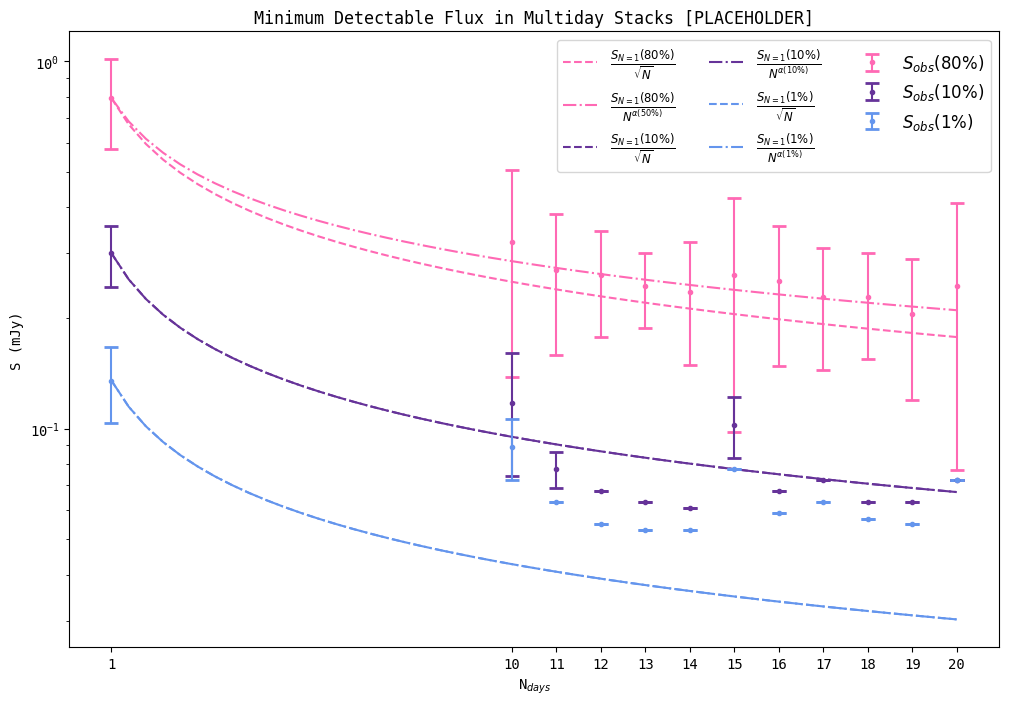

In [7]:
many_days = np.linspace(1, 20)


many_days = np.linspace(1, 20)

fig, ax = plt.subplots(figsize = (12, 8))

plt.errorbar(days, S_50, yerr = S_err50_up, label = r'$S_{obs}(80\%)$', color = 'hotpink',
             fmt = '.', capsize=5, capthick=2)
plt.plot(many_days, S_50[0] / np.sqrt(many_days), '--', color = 'hotpink',
         label = r'$\frac{S_{N = 1}(80\%)}{\sqrt{N}}$')
plt.plot(many_days, S_50[0] * many_days**alpha_80, '-.', color = 'hotpink',
         label = r'$\frac{S_{N = 1}(80\%)}{N^{\alpha(50\%)}}$')
plt.errorbar(days, S_10, yerr = S_err10_up, label = r'$S_{obs}(10\%)$', color = 'rebeccapurple',
             fmt = '.', capsize=5, capthick=2)
plt.plot(many_days, S_10[0] / np.sqrt(many_days), '--', color = 'rebeccapurple',
         label = r'$\frac{S_{N = 1}(10\%)}{\sqrt{N}}$')
plt.plot(many_days, S_10[0] * many_days**alpha_10, '-.', color = 'rebeccapurple',
         label = r'$\frac{S_{N = 1}(10\%)}{N^{\alpha(10\%)}}$')
plt.errorbar(days, S_1, yerr = S_err1_up, label = r'$S_{obs}(1\%)$', color = 'cornflowerblue',
             fmt = '.', capsize=5, capthick=2)
plt.plot(many_days, S_1[0] / np.sqrt(many_days), '--', color = 'cornflowerblue',
         label = r'$\frac{S_{N=1}(1\%)}{\sqrt{N}}$')
plt.plot(many_days, S_1[0] * many_days**alpha_1, '-.', color = 'cornflowerblue',
         label = r'$\frac{S_{N=1}(1\%)}{N^{\alpha(1\%)}}$')
plt.xlabel(r'N$_{days}$')
plt.ylabel('S (mJy)')
plt.legend(fontsize = 12, ncol = 3)
plt.title('Minimum Detectable Flux in Multiday Stacks [PLACEHOLDER]')
xticks = plt.xticks(days) 
plt.yscale('log')

$$S_N = S_1 N^{-0.4}$$
$$N = \left(\frac{S_N}{S_1} \right)^{-2.5} $$

In [8]:
def days_to_Smin(Smin, S1, alpha = 0.39):

    return (Smin / S1)**(-2.5)

Text(0.5, 1.0, 'Estimated Days to Reach Different Retrieval Percentages in CHAMPSS')

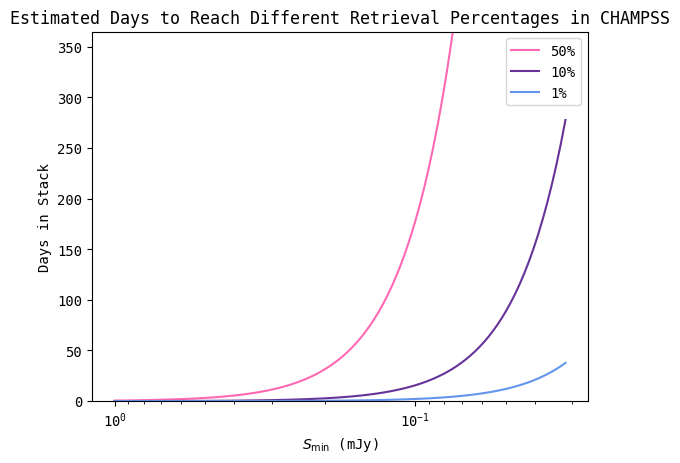

In [9]:
Smin = np.logspace(0, -1.5, 100)

plt.plot(Smin, days_to_Smin(Smin, S_50[0]), label = '50%', color = 'hotpink')
plt.plot(Smin, days_to_Smin(Smin, S_10[0]), label = '10%', color = 'rebeccapurple')
plt.plot(Smin, days_to_Smin(Smin, S_1[0]), label = '1%', color = 'cornflowerblue')
plt.xlabel(r'$S_{\min}$ (mJy)')
plt.ylabel('Days in Stack')
plt.legend()
plt.xscale('log')
plt.ylim(0, 365)
plt.gca().invert_xaxis()
plt.title('Estimated Days to Reach Different Retrieval Percentages in CHAMPSS')

Lorimer & Kramer:
$$S_{min} = \frac{\beta (T_{sys} + T_{sky})}{G} \frac{1}{\sqrt{N_{pol}\tau \Delta \nu}} \sqrt{\frac{\delta}{1 - \delta}} \text{SNR} $$

where $\delta$ is the effective width.

Assuming that we will find >50% of everything with SNR > 10, and choosing $b = 0^{\circ}$ and $l = 90^{\circ}$:

In [99]:
TSKY = 26 #K
GAIN = 1.16e-3  # K mJy^-1
TSYS = 30  # K
BETA = 1.1
NPOL = 2
TAU = 20* 10 * 60 #s
F_NYQUIST = 508 #Hz
BANDWIDTH = 400e6 #Hz

#envelope functions:
def get_nchans(maxdm):
    """
    Inputs a pointing dict with ra, dec, maxdm and returns nchans.

    Inputs
    pointing - A dict of ra, dec, maxdm
    """
    if maxdm <= 212.5:
        nchans = 1024
    elif maxdm <= 425:
        nchans = 2048
    elif maxdm <= 850:
        nchans = 4096
    elif maxdm <= 1700:
        nchans = 8192
    else:
        nchans = 16384
    return nchans


def get_dedispersion_time():

    #max DM offset we can have for channelization of 0.1 pcc
    delta_DM = 0.05 #pc / cm^-3 
    
    dt = DM_CONSTANT * delta_DM * (1/FREQ_BOTTOM**2 - 1/FREQ_TOP**2)
    
    return dt

def time_windowing(prof_fft, f):
    # apply Van der Klis Eq 2.19 for time-bin windowing effect
    harmonic_freqs = np.arange(1, len(prof_fft) + 1) * f
    B = np.sinc(harmonic_freqs * TSAMP)
    prof_fft *= B

    return prof_fft

def get_intrachannel_time(DM, maxDM):
        
    nchan = get_nchans(maxDM)

    quadratic_terms = {
            "1024": 1e-8,
            "2048": 6e-9,
            "4096": 3e-9,
            "8192": 1.5e-9,
            "16384": 8e-10,
        }
    quadratic_term = quadratic_terms[str(nchan)]

    t_intrachannel = DM * DM_CONSTANT * quadratic_term
    
    return t_intrachannel

def radiometer(f, DM, SNR, FWHM, maxDM, Ndays = 14):

    FWHM /= f #in s
    tau = Ndays * 10 * 60
 
    t_dedisp = get_dedispersion_time() #in s
    t_intrach = get_intrachannel_time(DM, maxDM)
    
    FWHM = np.sqrt(FWHM**2 + t_dedisp**2 + t_intrach**2 + TSAMP**2)

    system_terms =  BETA * (TSYS + TSKY) / GAIN
    obs_terms = 1 / np.sqrt(NPOL * tau * BANDWIDTH)
    pulse_terms = np.sqrt(FWHM / ((1 / f) - FWHM)) 

    return system_terms * obs_terms * pulse_terms * SNR

def get_Scurve(f, DM, maxDM, SNR = 10, FWHM = 0.01):

    Smin = np.zeros((len(DM), len(f)))

    for k in range(len(DM)):
        for l in range(len(f)):
            S_temp = radiometer(f[l], DM[k], SNR, FWHM, maxDM)
            Smin[k, l] = S_temp

    return Smin


Text(0.5, 1.0, 'Minimum Detectable Flux as a Function of Days in Stack [PLACEHOLDER]')

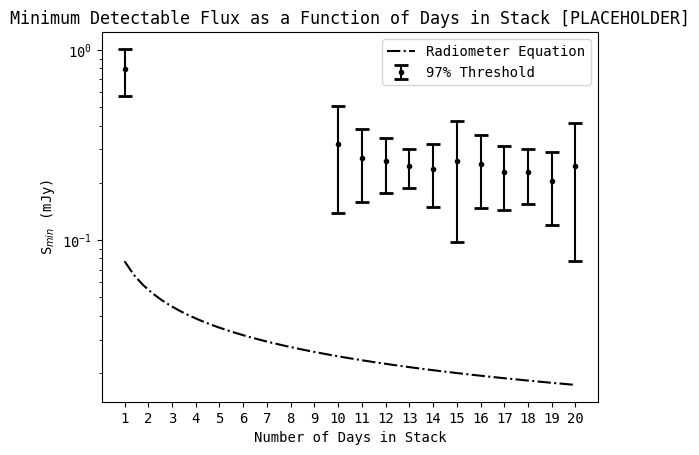

In [104]:
N = np.arange(1, 20)

Smin = radiometer(1, 10., 10., 0.01, 354, many_days)

#plt.plot(N, Smin)
plt.errorbar(days, S_50, yerr = S_err50_up, label = '97% Threshold', color = 'black',
             fmt = '.', capsize=5, capthick=2)
# plt.plot(many_days, S_50[0] / np.sqrt(many_days), '--', color = 'black',
#          label = r'$\frac{S_{N = 1}(80\%)}{\sqrt{N}}$')
plt.plot(many_days, Smin, '-.', color = 'black',
         label = 'Radiometer Equation')
plt.legend()
plt.xticks(range(1, 21))
plt.xlabel('Number of Days in Stack')
plt.ylabel(r'S$_{min}$ (mJy)')
plt.yscale('log')
plt.title('Minimum Detectable Flux as a Function of Days in Stack [PLACEHOLDER]')

Below is a really complicated way of sorting all our data into chunks based off the channelization.

In [77]:
import json

with open('/data1/people/rsquillace/Transmissivity/scripts/stack_maxdm.json', 
          'r') as file:
    maxDM_dict = json.load(file)

data_1k = []
data_2k = []
data_4k = []
data_8k = []
data_16k = []

key_strings = list(maxDM_dict.keys())
keys = np.zeros((len(key_strings), 2))
for i in range(len(key_strings)):
    keys[i, 0] = key_strings[i].split(' ')[0]
    keys[i, 1] = key_strings[i].split(' ')[1]

for i in range(len(data)):
    for j in range(len(data[i])):
        datum = data[i][j]
        closest_key_idx = np.argmin(np.sum((datum[:2] - keys)**2, axis = 1))
        #print((datum[:2] - keys)**2))

        datum_maxdm = maxDM_dict[key_strings[closest_key_idx]]
        nchan = get_nchans(datum_maxdm)

        if nchan == 1024:
            data_1k.append(datum)
        elif nchan == 2048:
            data_2k.append(datum)
        elif nchan == 4098:
            data_4k.append(datum)
        elif nchan == 8192:
            data_8k.append(datum)
        else:
            data_16k.append(datum)


    
data_1k = np.asarray(data_1k)
data_2k = np.asarray(data_2k)
data_4k = np.asarray(data_4k)
data_8k = np.asarray(data_8k)
data_16k = np.asarray(data_16k)

print('Done running. Try not to rerun this cell...')

Done running. Try not to rerun this cell...


1k 119852
2k: 42412
4k: 0
8k: 700
16k: 13917


/data1/people/rsquillace/Transmissivity/scripts/analysis_utils.py:32: RuntimeWarning: invalid value encountered in divide
  arr_ret_p_smooth = arr_ret_smooth / arr_inj_smooth
/data1/people/rsquillace/Transmissivity/scripts/analysis_utils.py:34: RuntimeWarning: invalid value encountered in divide
  arr_ret_p = arr_retrieved / arr_injected


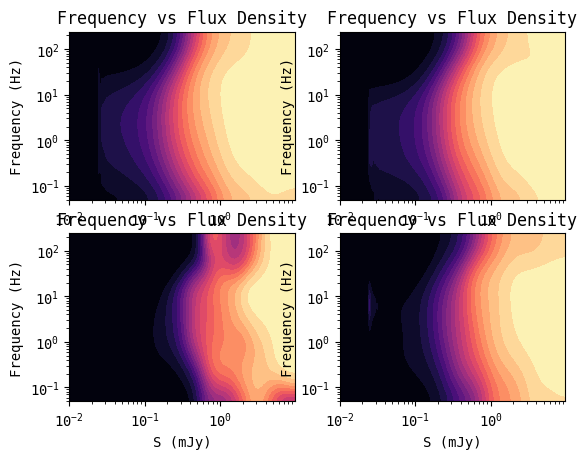

In [101]:
f_bins = np.logspace(np.log10(0.05), np.log10(250), 300)
f_dev = 30

print(f'1k {len(data_1k)}')
print(f'2k: {len(data_2k)}')
print(f'4k: {len(data_4k)}')
print(f'8k: {len(data_8k)}')
print(f'16k: {len(data_16k)}')

Smin_1k = np.zeros(len(f_bins) - 1)
Smin_2k = np.zeros(len(f_bins) - 1)
Smin_8k = np.zeros(len(f_bins) - 1)
Smin_16k = np.zeros(len(f_bins) - 1)

err_1k = np.zeros(len(f_bins) - 1)
err_2k = np.zeros(len(f_bins) - 1)
err_8k = np.zeros(len(f_bins) - 1)
err_16k = np.zeros(len(f_bins) - 1)

channelized_data = [data_1k, data_2k, data_8k, data_16k]
Smins = [Smin_1k, Smin_2k, Smin_8k, Smin_16k]
errs = [err_1k, err_2k, err_8k, err_16k]

fig, ax = plt.subplots(2, 2)
ax = ax.flatten()

for i in range(4):

    _, f_S_unsmooth, f_S_smooth = au.get_sensitivity(
        channelized_data[i],
        *(f_idx, S_idx, f_bins, S_bins, f_dev, S_dev),
        stype = '2d',
    )

    ax[i].contourf(S_bins[:-1], f_bins[:-1], f_S_smooth, 
                            levels=au.make_levels(f_S_unsmooth), cmap='magma')
    ax[i].set_xscale('log')
    ax[i].set_yscale('log')
    ax[i].set_ylabel('Frequency (Hz)')
    ax[i].set_xlabel('S (mJy)')
    ax[i].set_title('Frequency vs Flux Density')

    for j in range(len(f_bins) - 1):

        try:
            Smins[i][j] = np.min(S_bins[np.where(f_S_smooth[j] > 0.97)[0]])
        except:
            Smins[i][j] = np.nan
        #print(Smins[i][j])

        # p_50_idx = np.where(f_S_smooth[j] < 0.9)[0][-1]
        # local_std50 = np.std(f_S_unsmooth[j, p_50_idx - 10: p_50_idx + 10])
        # temp_err = np.max(f_S_smooth[j, np.where(f_S_smooth[j] < 0.9 + local_std50)[0]])
        # temp_err -= Smins[i][j]
        # errs[i][j] = temp_err


/tmp/ipykernel_1004018/2582896114.py:77: RuntimeWarning: invalid value encountered in sqrt
  pulse_terms = np.sqrt(FWHM / ((1 / f) - FWHM))


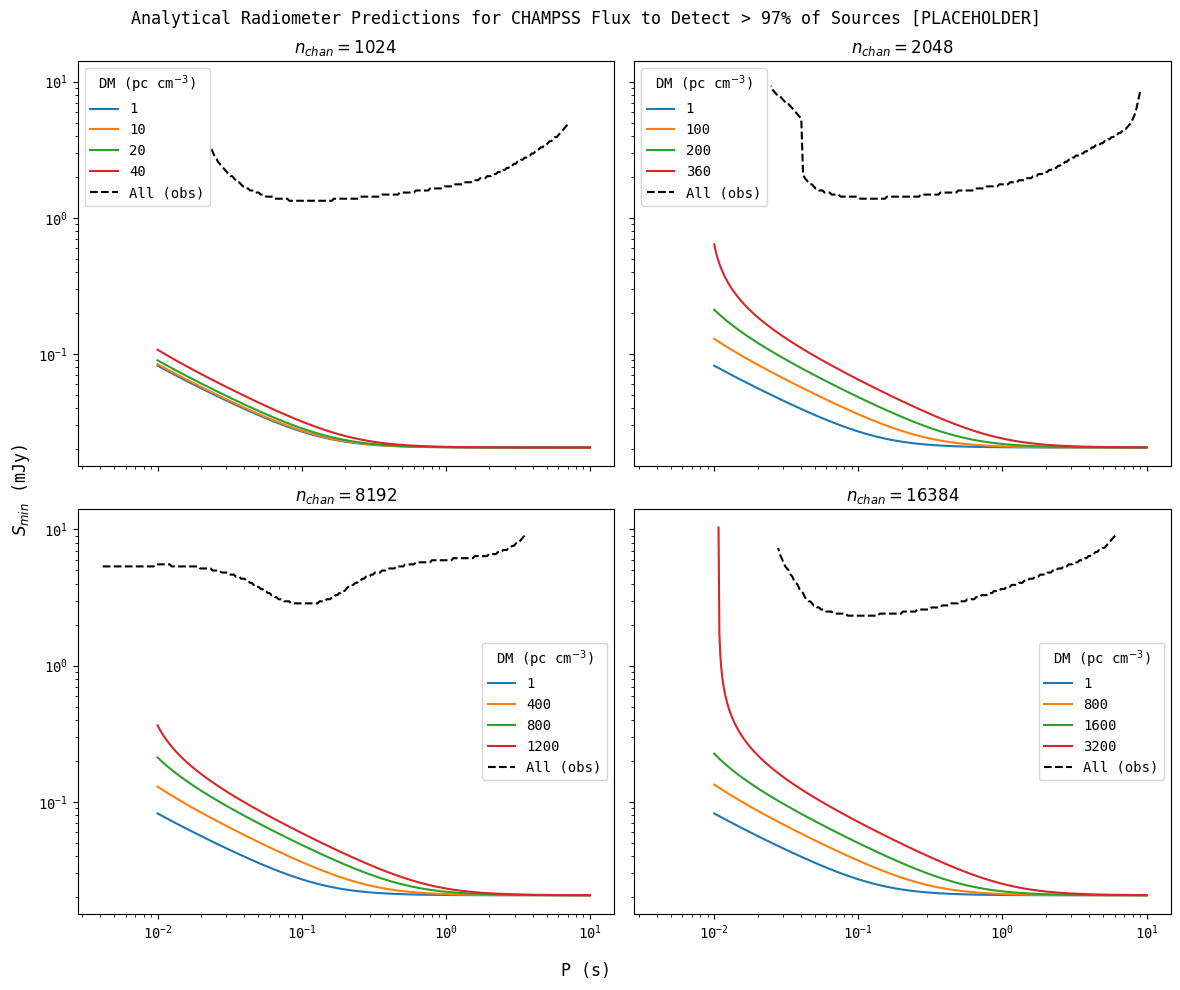

In [105]:
maxDMs = np.array([24, 350, 1000, 2000])
DMs = np.array([[1, 10, 20, 40],
                [1, 100, 200, 360],
                [1, 400, 800, 1200],
                [1, 800, 1600, 3200]
    ])
P = np.logspace(-2, 1, 500)
f = 1 / P

fig, ax = plt.subplots(2, 2, figsize = (12, 10), sharex = True, sharey = True)
ax = ax.flatten()

for i in range(len(maxDMs)):
    Scurve = get_Scurve(f, DMs[i], maxDMs[i])

    for j in range(len(DMs[i])):
        ax[i].plot(P, Scurve[j], label = DMs[i, j])

    
    ax[i].plot(1/f_bins[:-1], Smins[i], 'k--', label = 'All (obs)')
    ax[i].legend(title = r'DM (pc cm$^{-3}$)')


ax[0].set_xscale('log')
ax[0].set_title(r'$n_{chan} = 1024$')

ax[1].set_xscale('log')
ax[1].set_title(r'$n_{chan} = 2048$')

ax[2].set_xscale('log')
ax[2].set_title(r'$n_{chan} = 8192$')

ax[3].set_xscale('log')
ax[3].set_title(r'$n_{chan} = 16384$')
ax[3].set_yscale('log')

fig.supylabel('$S_{min}$ (mJy)')
fig.supxlabel('P (s)')
fig.suptitle('Analytical Radiometer Predictions for CHAMPSS Flux to \
Detect > 97% of Sources [PLACEHOLDER]')

plt.tight_layout()